# HBI&nbsp;01 — Synthetic end-to-end closure

**What this notebook does (in one breath):** we *invent* a known column-density
distribution $f(N)$, *forward-simulate* a DLA detection catalog from it (the
same physical effects the GP pipeline would impose — incompleteness and an
Eddington measurement smear), then run the **real production MAP deconvolution**
on that synthetic catalog and check we recover the $f(N)$ we put in.

```
   inject  f_b_true (known power law)
      │
      ▼  forward-simulate
   catalog of "measured" detections  N̂_i   (completeness-thinned + Eddington-smeared)
      │
      ▼  REAL production estimator  (cddf_catalog_hbi)
   MAP-deconvolved  f_rec
      │
      ▼  self-check
   dN/dX(≥20.3)_rec  ≈  dN/dX(≥20.3)_true   (within 8%)
```

**No GP inference. No scratch caches. No GPFS.** Everything runs in a couple of
seconds on a laptop. This is the cleanest possible setting to *see the math
work*: because the truth is something we chose, every intermediate quantity has
a known right answer, and the closure assertion at the end is checked against
the **injected truth**, not against a self-consistency recovery.

This notebook is a faithful, narrated adaptation of the production test
`tests/test_cddf_catalog_hbi.py::test_v2_synthetic_closure_recovers_injected_fb`
(the `_FakeXcalc` cosmology stub and `_make_cfg` config wrapper are copied
verbatim). Every printed number is computed by the code in the cell — nothing is
typed in.

> Companion notebooks: **NB2** swaps the synthetic forward kernel for the real
> 2LPT-0 forward kernel; **NB3** opens up the likelihood, the MAP solve, and the
> Monte-Carlo band.

---

📄 **Paper-draft correspondence**: this notebook ↔ **Method** §*Rate-form marked-Poisson likelihood* (Eqs. logL, λ_real, μ_det), §*Selection normalizer M & completeness C* (Eq. M_b), §*MAP inference* (Eq. prior); **Validation** §(1) *Mock-injection recovery*.


In [1]:
# --- canonical deterministic environment (BLAS pinned to 1 thread BEFORE numpy):
# The MAP solve is an L-BFGS-B over a sparse normal-equations system; its result
# is sensitive to BLAS thread scheduling, so we pin every threadpool to 1 for
# bit-for-bit reproducibility (this matches the production test harness).
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
for _v in ("OMP_NUM_THREADS","OPENBLAS_NUM_THREADS","MKL_NUM_THREADS","NUMEXPR_NUM_THREADS"):
    os.environ[_v] = "1"
import sys
from pathlib import Path
_root = next((p for p in (Path.cwd(), *Path.cwd().parents)
              if (p / "CDDF_analysis" / "hbi" / "cddf_catalog_hbi.py").exists()), None)
assert _root is not None, "repo root (CDDF_analysis/hbi/) not found"
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
DATA = _root / "CDDF_analysis" / "hbi" / "tutorial_data"
import numpy as np
from CDDF_analysis.hbi import cddf_catalog_hbi as H   # THE production estimator
import matplotlib.pyplot as plt
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
print("env ready | numpy", np.__version__, "| fixtures:", DATA.is_dir())

env ready | numpy 2.4.4 | fixtures: True


## A tiny cosmology stub

The estimator needs the absorption-distance element $dX/dz=(1+z)^2/E(z)$ to turn
a redshift window into a path length $\Delta X$ (the denominator of $dN/dX$).
For this synthetic test we only need *relative* path lengths, so we use a
minimal stand-in (`_FakeXcalc`) instead of the full `AbsorptionDistance` class.
It is copied **verbatim** from the test (lines 261–287).

In [2]:
class _FakeXcalc:
    """Minimal AbsorptionDistance stand-in with the dX/dz = (1+z)²/E(z) integral
    needed by build_M_b (deltaX) and the cosmology E(z)."""
    def __init__(self, Omega_m=0.279):
        self.Omega_m = Omega_m
        self._cache = {}

    def _E(self, z):
        return np.sqrt(self.Omega_m * (1 + z) ** 3 + (1 - self.Omega_m))

    def X(self, z):
        # numeric integral of (1+z)²/E from 0 to z (coarse; only relative used)
        key = round(float(z), 6)
        if key not in self._cache:
            zg = np.linspace(0, key, 2000)
            _trap = getattr(np, "trapezoid", getattr(np, "trapz", None))
            self._cache[key] = float(_trap((1 + zg) ** 2 / self._E(zg), zg))
        return self._cache[key]

    def deltaX(self, z1, z2):
        # vectorized + memoized on unique (z1,z2) pairs (identical windows -> fast)
        z1 = np.atleast_1d(np.asarray(z1, float))
        z2 = np.atleast_1d(np.asarray(z2, float))
        out = np.empty(len(z1))
        for i in range(len(z1)):
            out[i] = self.X(z2[i]) - self.X(z1[i])
        return out

## Configuration and the fine $(\log N, z)$ grid

`HBIConfig` is the production config dataclass. We build a minimal instance with
the **exact kwargs the closure test uses** (dummy paths — we never load a real
catalog here). The notable choices, all chosen to make the *closure* clean:

| kwarg | value | why |
|---|---|---|
| `logN_lo`, `logN_hi` | 20.0, 21.5 | the DLA tier we fit |
| `drop_top_bin_above` | 21.4 | drop the open top bin (so the injected truth, which tops at 21.4, never leaks above the grid) |
| `v2_logN_fit_floor` | 20.0 | the forward kernel is trustworthy at/above this |
| `occupancy_floor` | 1 | keep every populated $N$-bin active |
| `v2_z_fit_lo/hi/step` | 2.4, 2.6, 0.2 | a **single** fine $z$-bin spanning [2.4, 2.6] — the synthetic truth puts all absorbers in one $z$-bin, so extra empty $z$-columns would just dilute the path length |
| `zbins` | (2.4, 2.6) | matching coarse $z$-binning |
| `report_logN_limits` | (20.0, 20.3) | reporting integration limits |
| `v2_lambda_grid` | (1e-3,) | a single smoothing $\lambda$ (no L-curve to scan) |
| `v2_n_restart` | 3 | a few L-BFGS-B multi-starts |

`build_fine_grid` returns, per fine $N$-bin: lower/upper $\log N$ edges, the
**linear** bin-center column density $N_b$, and the **linear** bin width
$\Delta N_b$ (note: $f(N)$ is a density in $N$, not in $\log N$, so the linear
$\Delta N$ matters).

In [3]:
def make_cfg(**kw):
    '''Minimal HBIConfig with dummy paths (never loaded here) — same wrapper the
    test uses (_make_cfg). The kwargs below are the closure-test defaults.'''
    defaults = dict(
        catalog_dir="/dev/null", truth_path="/dev/null",
        bal_cat_path="/dev/null", molly_tsv="/dev/null", out_dir="/tmp",
        logN_lo=17.2, logN_hi=22.5, dlogN=0.1, drop_top_bin_above=22.4,
        zbins=(2.0, 2.5, 3.0, 3.5), report_logN_limits=(20.0, 20.3),
        H0=70.0, Omega_m=0.279,
    )
    defaults.update(kw)
    return H.HBIConfig(**defaults)


# the EXACT kwargs the closure test passes
cfg = make_cfg(
    logN_lo=20.0, logN_hi=21.5, drop_top_bin_above=21.4,
    v2_logN_fit_floor=20.0, occupancy_floor=1,
    v2_z_fit_lo=2.4, v2_z_fit_hi=2.6, v2_z_fit_step=0.2,
    zbins=(2.4, 2.6), report_logN_limits=(20.0, 20.3),
    v2_lambda_grid=(1e-3,), v2_n_restart=3,
)

logN_lo, logN_hi, N_b, dN_b = H.build_fine_grid(cfg)
n_nbins = len(logN_lo)
Xcalc = _FakeXcalc(cfg.Omega_m)

print(f"fine N-bins         : {n_nbins}")
print(f"logN edges          : [{logN_lo[0]:.2f} .. {logN_hi[-1]:.2f}]")
print(f"resp_kind (default) : {cfg.resp_kind!r}  "
      f"(legacy kappa object; see honesty cell)")
print(f"single fine z-bin   : [{cfg.v2_z_fit_lo}, {cfg.v2_z_fit_hi}]")

fine N-bins         : 14
logN edges          : [20.00 .. 21.40]
resp_kind (default) : 'kappa'  (legacy kappa object; see honesty cell)
single fine z-bin   : [2.4, 2.6]


## The estimand: a marked-Poisson likelihood

The catalog is modelled as an inhomogeneous (marked) Poisson process over the
detection plane. Writing $f_b$ for the binned CDDF heights we want to infer, the
log-likelihood is

$$
\log L
= -\bigl(\mu_{\rm det} + \mu_{\rm FP}\bigr)
\;+\; \sum_i w_i \,\log\!\bigl(\lambda_{{\rm real},i} + \lambda_{{\rm FP},i}\bigr).
$$

The two pieces:

- **Per-detection rate** $\lambda_{{\rm real},i} = (A\,f)_i$. The matrix $A$ is
  the **forward-response / deconvolution operator**: row $i$ spreads each true
  $N$-bin's contribution onto detection $i$ through the measurement kernel
  $N(\hat N_i \mid N,\sigma_i^2)$ and the cosmological $dX/dz$ weight. So
  $\lambda_{{\rm real},i}$ is the expected rate of *real* detections at $i$ given
  the underlying $f$.

- **Expected total real count** $\mu_{\rm det} = M\cdot f$. The vector $M$ is the
  **path-length normalizer**: $M_b = \Delta N_b \sum_s \Delta X_{s}$ (summed over
  sightlines), i.e. how much survey path length each $N$-bin is searched over.

- **Completeness** $C(N,{\rm SNR})$ enters as a forward **thinning probability**:
  $A$ and $M$ are each scaled by $\times C$ (`_apply_C_to_A` / `_apply_C_to_M`), so
  they predict the *detected* rate and count given the true $f(N)$ — not the true
  rate. Incompleteness is then undone by the MAP **inversion** of $A$ (the
  `_solve_one_lambda` deconvolution below), **not** by a per-detection $1/C$
  reweight. (That $1/C$ — "divide by $C$ to undo the thinning" — form is the v1
  $1/V_{\rm max}$ estimator, which this forward-HBI path does **not** use.)

- **False positives** ($\mu_{\rm FP}$, $\lambda_{{\rm FP},i}$) are a known
  background; in *this* controlled test there are none, so both are zero.

Maximizing $\log L$ (with a small $D_2$ smoothing penalty $\lambda_{\rm smooth}\,
\lVert D_2 \log_{10} f\rVert^2$ for stability) over $f \ge 0$ is the **MAP deconvolution**.
That solve is `H._solve_one_lambda`. Everything below assembles $A$, $M$, the
penalty, and runs that exact solver.

## A known completeness $C(N,{\rm SNR})$ and the injected truth $f_b^{\rm true}$

**Completeness** (`MollyMatrix`): two SNR cells split at 4, one $N$-cell over
$[20.0, 21.5)$. We make $C$ rise with SNR (0.80 for low-SNR sightlines, 0.95 for
high-SNR). This SNR$\to$completeness trend is physical: in a low-SNR spectrum the
broad Voigt trough is harder to distinguish from noise, so the absorber less often
clears the GP evidence threshold and is more often missed — hence lower
completeness. We keep $C$ **flat in $N$** within the DLA tier — deliberately no
sharp $C$
step at the 20.3 reporting boundary (a step there would couple the kernel width
to the boundary and create a hard Eddington amplification that a *controlled*
closure test should not have to fight; that boundary case is exercised on the
real catalog). Purity is 1 (no false positives).

**Injected truth**: a power law $f_b^{\rm true}=A\,N_b^{\beta}$ with
$\beta=-1.8$, normalized so $f(10^{20.3})=10^{-22}$. Because the fit grid tops at
21.4 = the truth top, no true system smears in from above the grid.

In [4]:
# known completeness matrix (Molly-style): rows = SNR cells, cols = N cells
snr_edges = np.array([0, 4, np.inf])
nhi_edges = np.array([20.0, 21.5])
C_mat = np.array([[0.8],    # SNR in [0,4)   -> 80% complete
                  [0.95]])  # SNR in [4,inf) -> 95% complete
mm = H.MollyMatrix(snr_edges=snr_edges, nhi_edges=nhi_edges,
                   purity=np.ones_like(C_mat), completeness=C_mat)

# injected power-law CDDF heights, f(N) = A N^beta
beta = -1.8
A = 1.0e-22 / (10.0 ** 20.3) ** beta     # f(10^20.3) = 1e-22 by construction
f_b_true = A * N_b ** beta

print(f"beta                : {beta}")
print(f"f(10^20.3)          : {A * (10.0**20.3)**beta:.3e}  (=1e-22 by design)")
print(f"completeness (SNR<4): {C_mat[0,0]:.2f}   (SNR>=4): {C_mat[1,0]:.2f}")

beta                : -1.8
f(10^20.3)          : 1.000e-22  (=1e-22 by design)
completeness (SNR<4): 0.80   (SNR>=4): 0.95


## Forward-simulate the "measured" catalog — step by step

This is the generative step: *exactly* what the GP pipeline does to nature, only
here done explicitly so we know the truth at every stage. We will watch the
catalog being **built from the injected truth**, one physical effect at a time,
with a figure after each step:

| step | effect | what you'll see |
|---|---|---|
| **A** | the injected truth $f_b^{\rm true}$ | the power law we are about to sample |
| **B** | expected detected counts per bin $f_b\,\Delta N_b\,\Delta X\,C$ | the mean catalog (no noise yet) |
| **C** | the Poisson realization | shot noise around the expectation |
| **D** | completeness thinning $C(N,{\rm SNR})$ | which true absorbers survive vs are missed |
| **E** | the Eddington $\hat N$ smear ($\sigma=0.02$) | up/down-scatter of the survivors |
| **F** | the resulting measured catalog $\hat x$ | the thing the MAP will deconvolve |

We run the generative loop **once** (cell below), recording every intermediate
array, and then narrate steps A–F off those recorded arrays — so the random-number
stream is drawn in the exact same order as the production test and the final
closure is bit-for-bit the test's.

> **Caveat — this Gaussian-in-$\log N$ smear is a deliberate teaching
> simplification.** A symmetric, $N$-independent Gaussian is *not* the real GP-DLA
> posterior kernel. The genuine forward response is **asymmetric**,
> **prior-informed** (it piles up against the $\log N \approx 20.3$ edge), and
> **$N$-dependent** in both center and width. We use a clean Gaussian here only so
> the closure math is transparent; the real measured forward response is built and
> inverted in **NB2** (`resp_kind="forward"`).

In [5]:
rng = np.random.default_rng(7)   # match the production test exactly

# many sightlines so the searched path length (M_b) is large; window [2.4,2.6]
n_sl = 200000
qso_zlo = np.full(n_sl, 2.4)
qso_zhi = np.full(n_sl, 2.6)
qso_snr = rng.choice([2.5, 10.0], size=n_sl, p=[0.5, 0.5])
z_edges_fine = H._fine_z_grid(cfg)

dX_sl = float(Xcalc.deltaX(2.4, 2.6)[0])     # per-sightline path length
sigma_kernel = 0.02                          # sub-bin Eddington smear (near-delta)
snr_cells = [2.5, 10.0]                       # SNR class representative values
C_interp = H.make_C_interpolator(mm)

# Per-(SNR cell, N-bin) bookkeeping so each forward step can be visualized.
# Rows = SNR cells, cols = fine N-bins.
exp_true   = np.zeros((len(snr_cells), n_nbins))   # B: expected TRUE count (mean)
cnt_true   = np.zeros((len(snr_cells), n_nbins))   # C: Poisson-drawn TRUE count
cnt_det    = np.zeros((len(snr_cells), n_nbins))   # D: survivors after completeness

obs_xhat = []; obs_snr = []; obs_zhat = []
xt_all_true = []      # E: true logN of EVERY drawn absorber (det + missed)
det_all     = []      # E: detection mask aligned to xt_all_true
xt_det_true = []      # E: true logN of survivors only (pre-smear)

# forward-simulate detections, SNR class by SNR class, N-bin by N-bin
# (RNG call order is IDENTICAL to the production test: poisson, uniform, random,
#  normal, uniform -- so the closure below is bit-for-bit the test's.)
for c, snr_cell in enumerate(snr_cells):
    n_sl_c = int((qso_snr == snr_cell).sum())
    dX_c = n_sl_c * dX_sl
    for b in range(n_nbins):
        mean_true = f_b_true[b] * dN_b[b] * dX_c     # expected TRUE count in this bin
        exp_true[c, b] = mean_true
        n_true = rng.poisson(mean_true)
        cnt_true[c, b] = n_true
        if n_true == 0:
            continue
        xt = rng.uniform(logN_lo[b], logN_hi[b], n_true)     # true logN
        Cdet = C_interp(xt, np.full(n_true, snr_cell))
        det = rng.random(n_true) < Cdet                      # completeness thinning
        cnt_det[c, b] = int(det.sum())
        xt_all_true.append(xt); det_all.append(det)
        xt_kept = xt[det]
        xt_det_true.append(xt_kept)
        xhat = xt_kept + rng.normal(0.0, sigma_kernel, len(xt_kept))   # Eddington smear
        obs_xhat.append(xhat)
        obs_snr.append(np.full(len(xt_kept), snr_cell))
        obs_zhat.append(rng.uniform(2.4, 2.6, len(xt_kept)))

obs_xhat = np.concatenate(obs_xhat)
obs_snr = np.concatenate(obs_snr)
obs_zhat = np.concatenate(obs_zhat)
xt_all_true = np.concatenate(xt_all_true)
det_all = np.concatenate(det_all)
xt_det_true = np.concatenate(xt_det_true)
n_obs = len(obs_xhat)
assert n_obs > 2000, f"test mis-tuned, only {n_obs} detections"

# the measured-catalog dict the estimator consumes
i_snr = H._cell_index(mm, obs_xhat, obs_snr)[0]
cat_op = dict(xhat=obs_xhat, zhat=obs_zhat,
              sig_x=np.full(n_obs, sigma_kernel),
              sig_z=np.full(n_obs, 1e-4), snr=obs_snr, i_snr=i_snr)

print(f"n_sl (sightlines)   : {n_sl}")
print(f"n_true total drawn  : {int(cnt_true.sum())}")
print(f"n_det  (survived C) : {int(cnt_det.sum())}")
print(f"n_obs (detections)  : {n_obs}   (need > 2000)  -> OK")
print(f"sigma_kernel        : {sigma_kernel} dex  (near-delta, sub-bin)")

n_sl (sightlines)   : 200000
n_true total drawn  : 5444
n_det  (survived C) : 4804
n_obs (detections)  : 4804   (need > 2000)  -> OK
sigma_kernel        : 0.02 dex  (near-delta, sub-bin)


### Step A — the injected truth $f_b^{\rm true}$

Everything downstream is a sampling of *this* curve. It is the same power law from
the previous cell ($\beta=-1.8$, anchored at $f(10^{20.3})=10^{-22}$); plotting it
on a log-$y$ axis shows the straight power-law line we will try to recover at the
very end. The $\ge 20.3$ DLA reporting floor is marked.

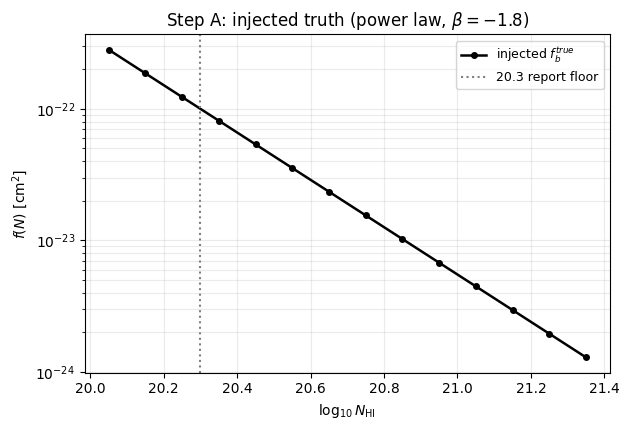

In [6]:
logN_ctr = 0.5 * (logN_lo + logN_hi)
fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.plot(logN_ctr, f_b_true, "k-o", ms=4, lw=1.8, label=r"injected $f_b^{true}$")
ax.axvline(20.3, ls=":", color="gray", label="20.3 report floor")
ax.set_yscale("log")
ax.set_xlabel(r"$\log_{10} N_{\rm HI}$")
ax.set_ylabel(r"$f(N)\ \mathrm{[cm^2]}$")
ax.set_title(r"Step A: injected truth (power law, $\beta=-1.8$)")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
plt.show()

### Step B — expected counts per $N$-bin (the mean catalog, no noise)

Before any randomness, the **expected** number of true absorbers per bin is
$\mu_b = f_b^{\rm true}\,\Delta N_b\,\Delta X_c$ — the injected CDDF times the
linear bin width times the searched path length of that SNR class. Because the
two SNR classes have (here) equal numbers of sightlines, their $\Delta X_c$ — and
so their expected counts — are nearly equal. The bars below are this *mean*
catalog: what we'd get with no shot noise and no thinning.

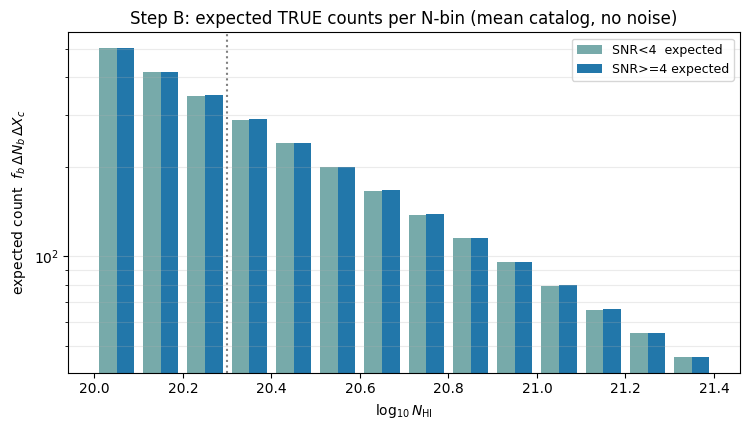

total expected true count: 5515


In [7]:
logN_ctr = 0.5 * (logN_lo + logN_hi)
fig, ax = plt.subplots(figsize=(7.6, 4.4))
w = 0.04
ax.bar(logN_ctr - w/2, exp_true[0], width=w, color="#7aa", label="SNR<4  expected")
ax.bar(logN_ctr + w/2, exp_true[1], width=w, color="#27a", label="SNR>=4 expected")
ax.axvline(20.3, ls=":", color="gray")
ax.set_yscale("log")
ax.set_xlabel(r"$\log_{10} N_{\rm HI}$")
ax.set_ylabel(r"expected count  $f_b\,\Delta N_b\,\Delta X_c$")
ax.set_title("Step B: expected TRUE counts per N-bin (mean catalog, no noise)")
ax.legend(fontsize=9)
ax.grid(True, which="both", axis="y", alpha=0.25)
fig.tight_layout()
plt.show()
print("total expected true count: %.0f" % exp_true.sum())

### Step C — the Poisson realization (shot noise)

Each bin's **actual** true count is a single Poisson draw with that mean. Overlaying
the drawn counts (markers) on the expectation (step lines) shows the shot noise:
small at the well-populated low-$N$ bins, large (and frequently zero) in the
sparse high-$N$ tail. This is the irreducible statistical scatter every survey
fights.

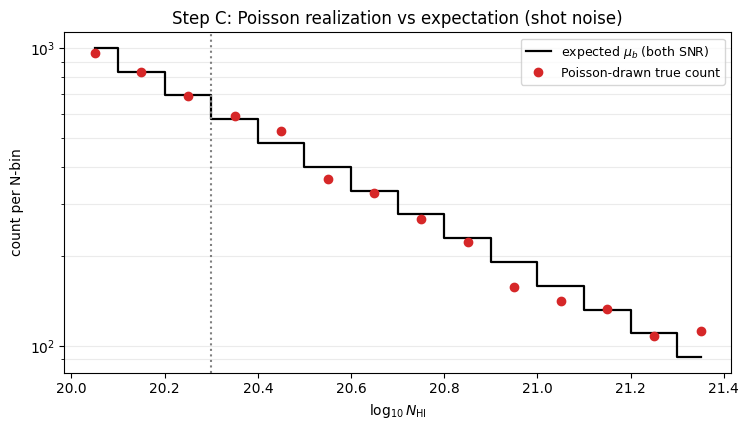

expected total 5515  vs  drawn total 5444


In [8]:
logN_ctr = 0.5 * (logN_lo + logN_hi)
exp_tot = exp_true.sum(axis=0)
cnt_tot = cnt_true.sum(axis=0)
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.step(logN_ctr, exp_tot, where="mid", color="k", lw=1.6,
        label=r"expected $\mu_b$ (both SNR)")
ax.plot(logN_ctr, cnt_tot, "o", ms=6, color="tab:red",
        label="Poisson-drawn true count")
ax.axvline(20.3, ls=":", color="gray")
ax.set_yscale("log")
ax.set_xlabel(r"$\log_{10} N_{\rm HI}$")
ax.set_ylabel("count per N-bin")
ax.set_title("Step C: Poisson realization vs expectation (shot noise)")
ax.legend(fontsize=9)
ax.grid(True, which="both", axis="y", alpha=0.25)
fig.tight_layout()
plt.show()
print("expected total %.0f  vs  drawn total %d" % (exp_tot.sum(), int(cnt_tot.sum())))

### Step D — completeness thinning $C(N,{\rm SNR})$

Each true absorber is **kept** with probability $C$ (here 0.80 for SNR$<$4, 0.95
for SNR$\ge$4) and otherwise *missed entirely*. This is the incompleteness that
makes a raw count too low. Left: per-bin true vs surviving counts (the gap is the
missed systems). Right: the overall kept/missed split per SNR class — the lower-SNR
class loses noticeably more. The MAP step later **undoes** exactly this thinning by
inverting the forward operator (not by a $1/C$ reweight).

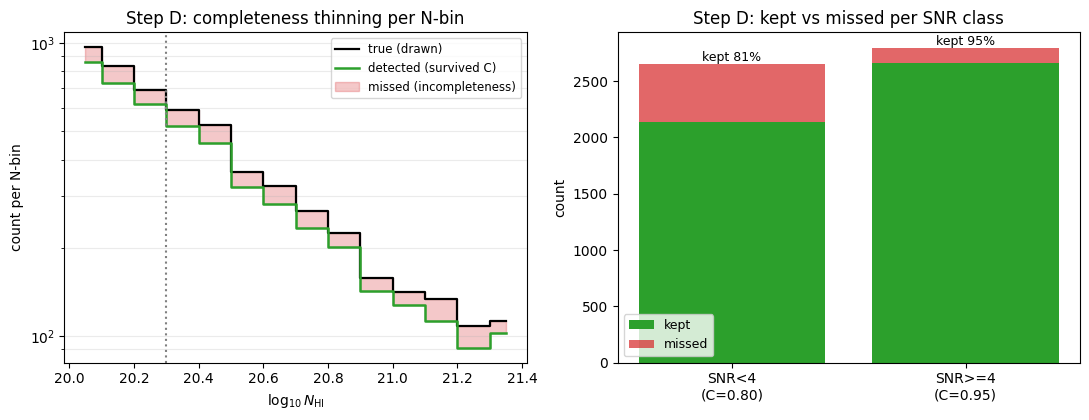

In [9]:
logN_ctr = 0.5 * (logN_lo + logN_hi)
cnt_true_tot = cnt_true.sum(axis=0)
cnt_det_tot  = cnt_det.sum(axis=0)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.3))

axL.step(logN_ctr, cnt_true_tot, where="mid", color="k", lw=1.6, label="true (drawn)")
axL.step(logN_ctr, cnt_det_tot,  where="mid", color="tab:green", lw=1.8,
         label="detected (survived C)")
axL.fill_between(logN_ctr, cnt_det_tot, cnt_true_tot, step="mid",
                 color="tab:red", alpha=0.25, label="missed (incompleteness)")
axL.axvline(20.3, ls=":", color="gray")
axL.set_yscale("log")
axL.set_xlabel(r"$\log_{10} N_{\rm HI}$"); axL.set_ylabel("count per N-bin")
axL.set_title("Step D: completeness thinning per N-bin")
axL.legend(fontsize=8.5)
axL.grid(True, which="both", axis="y", alpha=0.25)

kept   = cnt_det.sum(axis=1)
missed = cnt_true.sum(axis=1) - kept
x = np.arange(2)
axR.bar(x, kept,   color="tab:green", label="kept")
axR.bar(x, missed, bottom=kept, color="tab:red", alpha=0.7, label="missed")
for i in range(2):
    frac = kept[i] / (kept[i] + missed[i])
    axR.annotate("kept %.0f%%" % (100*frac), (i, kept[i] + missed[i]),
                 ha="center", va="bottom", fontsize=9)
axR.set_xticks(x); axR.set_xticklabels(["SNR<4\n(C=0.80)", "SNR>=4\n(C=0.95)"])
axR.set_ylabel("count"); axR.set_title("Step D: kept vs missed per SNR class")
axR.legend(fontsize=9)
fig.tight_layout()
plt.show()

### Step E — the Eddington $\hat N$ smear

The survivors get a **measured** column density $\hat N = N_{\rm true} +
\mathcal{N}(0,\sigma^2)$, $\sigma=0.02$ dex — a sub-bin, *near-delta* kernel. This
is the $\sigma\to 0$ anchor: with such a narrow kernel the deconvolution reduces to
a plain $1/V_{\rm max}$ count, isolating the forward-model **normalization** ($A$/$M$)
and the solve mechanics from genuine ill-conditioned deconvolution. The histogram
overlays the survivors' $N_{\rm true}$ and their smeared $\hat N$; the inset zoom
shows the tiny per-object up/down scatter (a real GP kernel would be wider and
*asymmetric* — that is NB2).

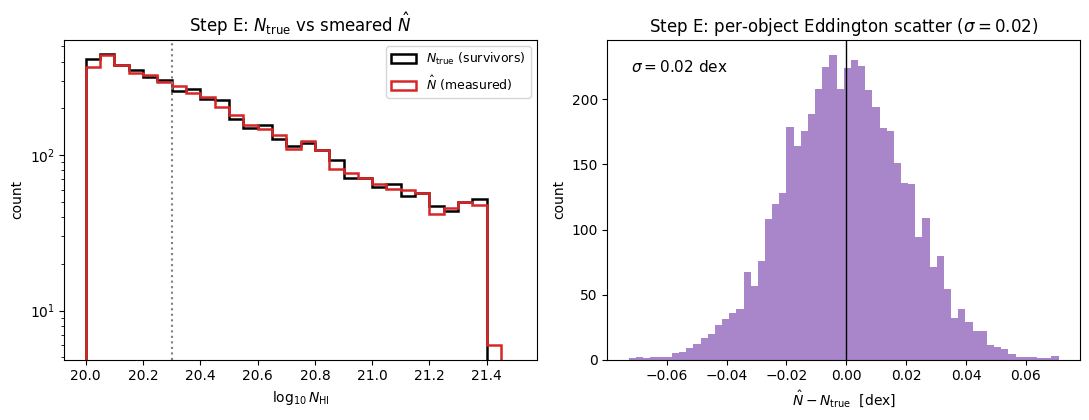

measured scatter std: 0.0202 dex  (injected sigma = 0.02)


In [10]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.3))
bins = np.arange(20.0, 21.5 + 1e-9, 0.05)
axL.hist(xt_det_true, bins=bins, color="k", histtype="step", lw=1.8,
         label=r"$N_{\rm true}$ (survivors)")
axL.hist(obs_xhat, bins=bins, color="tab:red", histtype="step", lw=1.8,
         label=r"$\hat N$ (measured)")
axL.axvline(20.3, ls=":", color="gray")
axL.set_yscale("log")
axL.set_xlabel(r"$\log_{10} N_{\rm HI}$"); axL.set_ylabel("count")
axL.set_title(r"Step E: $N_{\rm true}$ vs smeared $\hat N$")
axL.legend(fontsize=9)

# per-object residual hat - true (only valid because sigma is tiny: order preserved)
resid = obs_xhat - xt_det_true
axR.hist(resid, bins=60, color="tab:purple", alpha=0.8)
axR.axvline(0, color="k", lw=1.0)
axR.set_xlabel(r"$\hat N - N_{\rm true}$  [dex]")
axR.set_ylabel("count")
axR.set_title(r"Step E: per-object Eddington scatter ($\sigma=0.02$)")
axR.annotate(r"$\sigma=%.2f$ dex" % sigma_kernel, (0.05, 0.9),
             xycoords="axes fraction", fontsize=11)
fig.tight_layout()
plt.show()
print("measured scatter std: %.4f dex  (injected sigma = %.2f)"
      % (resid.std(), sigma_kernel))

### Step F — the measured catalog the MAP will deconvolve

This is `cat_op`: the dict of measured detections $\hat x$, their SNR class, and a
per-object kernel width $\sigma_i$ — the only thing the estimator gets to see (it
never sees $N_{\rm true}$ or the completeness draws). Below, the measured-catalog
$\hat N$ histogram split by SNR class. The MAP deconvolution in the next section
takes *exactly this* and inverts the forward model (completeness $+$ kernel) to
recover the Step-A truth.

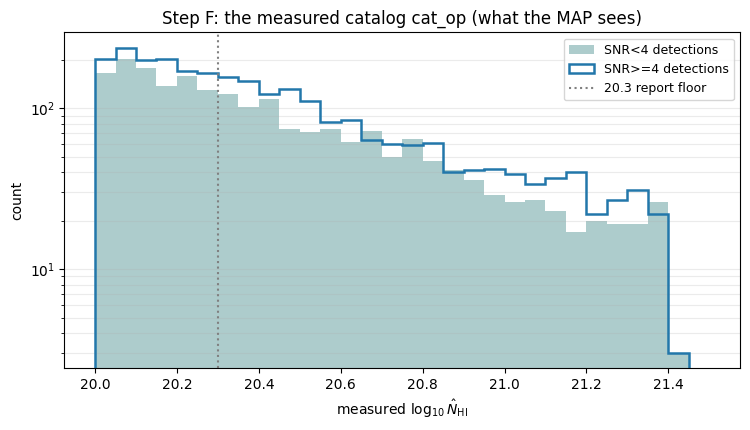

cat_op keys: i_snr, sig_x, sig_z, snr, xhat, zhat
n_obs in cat_op: 4804   (SNR<4: 2141, SNR>=4: 2663)


In [11]:
fig, ax = plt.subplots(figsize=(7.6, 4.4))
bins = np.arange(20.0, 21.5 + 1e-9, 0.05)
lo = obs_snr < 4
ax.hist(obs_xhat[lo],  bins=bins, color="#7aa", histtype="stepfilled",
        alpha=0.6, label="SNR<4 detections")
ax.hist(obs_xhat[~lo], bins=bins, color="#27a", histtype="step", lw=1.8,
        label="SNR>=4 detections")
ax.axvline(20.3, ls=":", color="gray", label="20.3 report floor")
ax.set_yscale("log")
ax.set_xlabel(r"measured $\log_{10}\hat N_{\rm HI}$")
ax.set_ylabel("count")
ax.set_title("Step F: the measured catalog cat_op (what the MAP sees)")
ax.legend(fontsize=9)
ax.grid(True, which="both", axis="y", alpha=0.25)
fig.tight_layout()
plt.show()
print("cat_op keys: %s" % ", ".join(sorted(cat_op)))
print("n_obs in cat_op: %d   (SNR<4: %d, SNR>=4: %d)"
      % (n_obs, int(lo.sum()), int((~lo).sum())))

## Assemble $A$, $M$, the penalty, and run the production MAP solve

Now the real estimator pieces, in the same order as the production test:

1. `build_A_ib(...)[1]` → the per-object forward response $A$ (unit-$C$ form +
   metadata; we keep the metadata, index `[1]`).
2. `build_M_b(...)` → the path-length normalizer $M$.
3. `_apply_C_to_A` / `_apply_C_to_M` → fold in the known completeness as a forward
   thinning probability: $A$ and $M$ are each scaled by $\times C$, so they predict
   the *detected* rate and count given the true $f$. Incompleteness is undone by the
   MAP **inversion** of $A$ in step 6 — **not** by a per-detection $1/C$ reweight
   (that $1/C$ form is the v1 $1/V_{\rm max}$ estimator, not used here).
4. Build the **active 2-D index** (which $(N,z)$ cells have support) and the
   $D_2$ smoothing operator with `_build_D2_operator`; map active columns back to
   the flat $(N,z)$ layout.
5. **Warm-start at the injected truth** `x0 = f_b_true` (the solve must *stay*
   near it, not run away) plus a flat fallback start.
6. `_solve_one_lambda(A_act, M_act, lam_fp=0, mu_fp=0, λ=1e-3, D2, [x0, x0_flat])`
   → the MAP heights $f_{\rm best}$. We map them back to the full $N$-grid as
   `f_rec`.

There is **no false-positive background** in this controlled test, so
`lam_fp = 0` and `mu_fp = 0`.

In [12]:
# 1+2: forward response A (keep metadata = index [1]) and normalizer M
A_meta = H.build_A_ib(cat_op, mm, logN_lo, logN_hi, N_b, dN_b, z_edges_fine,
                      Xcalc, cfg, kernel="gaussian")[1]
M_meta = H.build_M_b(qso_zlo, qso_zhi, qso_snr, mm, logN_lo, logN_hi, N_b, dN_b,
                     z_edges_fine, Xcalc, cfg)

# 3: fold in the known completeness as a forward thinning probability. BOTH A and M
# are scaled by xC (NOT x1/C) -- they predict the DETECTED rate/count given true f.
# Incompleteness is undone by the MAP inversion of A below, not a per-row 1/C reweight
# (the 1/C form is the v1 1/Vmax estimator, not used here).
A_full = H._apply_C_to_A(A_meta, mm.completeness)
M_full = H._apply_C_to_M(M_meta, mm.completeness)

# 4: active (N,z) cells (occupancy_floor=1 -> any populated column) + D2 penalty
n_zf = len(z_edges_fine) - 1
col_nnz = np.asarray((A_full != 0).sum(axis=0)).ravel().reshape(n_nbins, n_zf)
active_2d = col_nnz > 0
D2, act_idx, n_active = H._build_D2_operator(n_nbins, n_zf, active_2d)

# map each active column back to its flat (jN*n_zf + kz) position
active_flat_cols = np.zeros(n_active, int)
for kz in range(n_zf):
    for jN in range(n_nbins):
        ai = act_idx[jN, kz]
        if ai >= 0:
            active_flat_cols[ai] = jN * n_zf + kz
A_act = A_full[:, active_flat_cols].tocsr()
M_act = M_full[active_flat_cols]

# 5: no FP here; warm-start at the injected truth + a flat fallback start
lam_fp = np.zeros(n_obs)
mu_fp = 0.0
x0 = np.zeros(n_active)
for kz in range(n_zf):
    for jN in range(n_nbins):
        ai = act_idx[jN, kz]
        if ai >= 0:
            x0[ai] = f_b_true[jN]
x0_flat = np.full(n_active, np.median(f_b_true))

# 6: THE production MAP solve
f_best, negP, _ = H._solve_one_lambda(A_act, M_act, lam_fp, mu_fp,
                                      1e-3, D2, [x0, x0_flat])

# map the active solution back onto the full N-grid
f_rec = np.zeros(n_nbins)
for kz in range(n_zf):
    for jN in range(n_nbins):
        ai = act_idx[jN, kz]
        if ai >= 0:
            f_rec[jN] += f_best[ai]

print(f"n_active cells      : {n_active}")
print(f"negP (MAP -logpost) : {negP:.4g}")
print(f"f_rec (head)        : {np.array2string(f_rec[:4], precision=3)}")

n_active cells      : 14
negP (MAP -logpost) : 1.557e+04
f_rec (head)        : [2.822e-22 1.841e-22 1.234e-22 8.622e-23]


## Visualize: injected vs recovered

Left: the recovered CDDF heights $f_{\rm rec}$ over the injected truth
$f_b^{\rm true}$ (log-$y$). Right: the integrated $dN/dX(\ge 20.3)$ — truth vs
recovery as two bars. If the deconvolution is doing its job, the curves overlay
and the bars match.

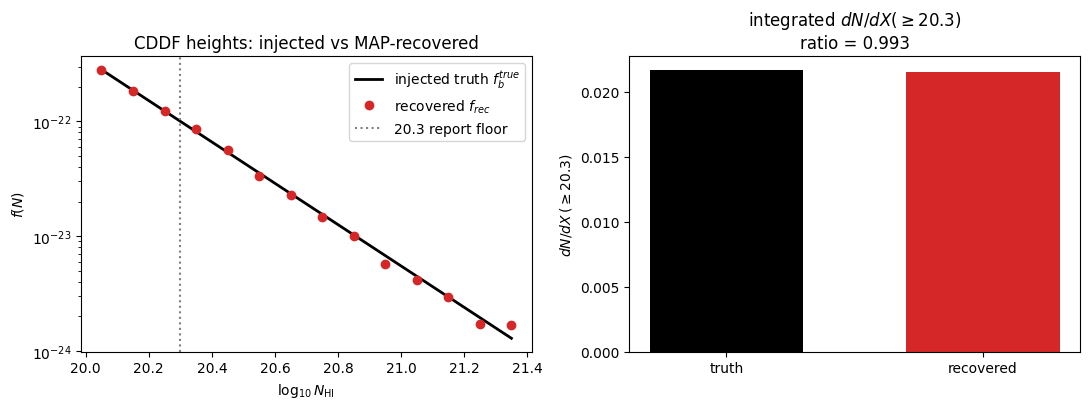

In [13]:
logN_ctr = 0.5 * (logN_lo + logN_hi)
sel = logN_lo >= 20.3 - 1e-9
dndx_rec = float(np.sum(f_rec[sel] * dN_b[sel]))
dndx_true = float(np.sum(f_b_true[sel] * dN_b[sel]))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))

axL.plot(logN_ctr, f_b_true, "k-", lw=2, label="injected truth $f_b^{true}$")
axL.plot(logN_ctr, f_rec, "o", ms=6, color="tab:red", label="recovered $f_{rec}$")
axL.axvline(20.3, ls=":", color="gray", label="20.3 report floor")
axL.set_yscale("log")
axL.set_xlabel(r"$\log_{10} N_{\rm HI}$")
axL.set_ylabel(r"$f(N)$")
axL.set_title("CDDF heights: injected vs MAP-recovered")
axL.legend()

axR.bar([0, 1], [dndx_true, dndx_rec], color=["k", "tab:red"], width=0.6)
axR.set_xticks([0, 1])
axR.set_xticklabels(["truth", "recovered"])
axR.set_ylabel(r"$dN/dX\,(\geq 20.3)$")
axR.set_title(f"integrated $dN/dX(\\geq 20.3)$\nratio = {dndx_rec/dndx_true:.3f}")

fig.tight_layout()
plt.show()

## The closure self-check

The same assertion the production test makes: the deconvolved integrated
$dN/dX(\ge 20.3)$ must match the **injected truth** within 8%.

In [14]:
sel = logN_lo >= 20.3 - 1e-9
dndx_rec = float(np.sum(f_rec[sel] * dN_b[sel]))
dndx_true = float(np.sum(f_b_true[sel] * dN_b[sel]))
ratio = dndx_rec / dndx_true

assert abs(dndx_rec - dndx_true) / dndx_true < 0.08, (
    f"closure off: rec={dndx_rec:.5g} true={dndx_true:.5g} (ratio {ratio:.3f})")

print(f"dN/dX(>=20.3) true  : {dndx_true:.6g}")
print(f"dN/dX(>=20.3) rec   : {dndx_rec:.6g}")
print(f"ratio rec/true      : {ratio:.4f}")
print(f"n_obs               : {n_obs}")
print(f"|ratio - 1|         : {abs(ratio - 1):.4f}  (<0.08 required)")
print("\nCLOSURE PASS — the MAP deconvolution recovered the injected truth.")

dN/dX(>=20.3) true  : 0.0216702
dN/dX(>=20.3) rec   : 0.0215262
ratio rec/true      : 0.9934
n_obs               : 4804
|ratio - 1|         : 0.0066  (<0.08 required)

CLOSURE PASS — the MAP deconvolution recovered the injected truth.


## Honesty: what this test does and does not prove

Read this before you over-interpret the green checkmark.

**(a) Why the self-check is non-circular here — and where circularity *would*
creep in.** The assertion above compares the recovered $dN/dX$ to the
**injected** truth — a quantity we chose, completely independent of the catalog
the estimator saw. That is a genuine closure test of the forward model + solve.

The thing to *not* do is confuse this with an "$\alpha = 1/R_0$" recovery. On a
*real mock*, one fits the completeness/kernel on the same truth used to *score*
the recovery; then the recovered-over-truth ratio is driven to 1 essentially **by
construction** — a tautology, not evidence. The honest external test of the
method is **cross-mock transfer**: build the kernel on one mock, apply it to a
held-out mock of a *different* recipe, and check $R_0(z)\approx 1$ *without*
refitting. That is **NB4** (future) — not this notebook. (In the paper draft the *headline* non-circularity evidence is the **full-injection closure** — inject tilted DLAs, re-run the GP, recover with the frozen kernel — with cross-mock transfer as a complementary leg.)

**(b) The injected abundance is below DESI scale — on purpose.** The injected
$dN/dX(\ge 20.3)\approx 0.022$ here is only $\sim$40% of the 2LPT-0 mock truth
($\approx 0.054$). That is **intentional**: this closure test checks that the MAP
**recovers what was injected**, not that the injected abundance matches the DESI
expectation. The absolute scale of the synthetic truth is irrelevant to whether the
forward model + solve close; real-scale numbers (and the comparison to the mock
truth) live in the validation notebook, not here.

**(c) There is no error band here, and the band you'll see elsewhere is
statistical only.** This notebook reports a single point recovery. The
Monte-Carlo band shown in **NB3** quantifies *statistical* uncertainty only — it
is **not** the total systematic $\sigma_{\rm tot}$. Completeness/kernel
mis-specification and the Eddington high-$N$ amplification are separate
systematics that the band does not capture.

**(d) `resp_kind="kappa"` is a legacy default — do not audit the dataclass
default and call it the method.** `HBIConfig` defaults `resp_kind="kappa"`, which
builds $A$ from the cached **GP-posterior** $\kappa$ object purely for
byte-identical backward reproduction. The **headline science pipeline sets
`resp_kind="forward"`**, which builds $A$ from the *forward likelihood*
$p(\hat N\mid N,{\rm SNR},z)$ — the object that removes the narrow-kappa high-$N$
over-recovery. This synthetic notebook supplies its *own* Gaussian forward kernel
directly via `build_A_ib(..., kernel="gaussian")`, so it does not exercise either
production response path; it exercises the **normalization and solve mechanics**.
Auditing the dataclass default in isolation mis-reconstructs the production
method — read NB2 for the real forward kernel.

## Recap and where to go next

We injected a known power-law $f(N)$, forward-simulated a completeness-thinned,
Eddington-smeared detection catalog, fed it to the **real production MAP
deconvolution** (`cddf_catalog_hbi._solve_one_lambda` with the production
$A$/$M$/penalty assembly), and recovered the injected $dN/dX(\ge 20.3)$ within
8% — all in a couple of seconds, with no GP inference, no caches, no GPFS.

The near-delta ($\sigma=0.02$ dex) kernel made this the $\sigma\to 0$ anchor,
where the deconvolution reduces to a $1/V_{\rm max}$ count and the test isolates
the forward-model normalization and solve mechanics.

**Next:**
- **NB2** — replace the synthetic Gaussian forward kernel with the *real* 2LPT-0
  forward kernel (`resp_kind="forward"`) and watch the genuine finite-width
  deconvolution at work.
- **NB3** — open up the marked-Poisson likelihood, the MAP solve internals, and
  the Monte-Carlo statistical band.